## globally optimal stewy

Goal: Given a run of data, compute an optimal trajectory over the entire horizon (not MPC).

In [1]:
%matplotlib ipympl

import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import functools
import jax.numpy as jnp
import numpy as np
import pandas as pd
import control as ct
import tqdm
import matplotlib.pyplot as plt  # leave for convenient debugging
import scipy.optimize as sci_opt

import lbfgs.lbfgs as lbfgs
import exp_mpc.stewart_min.siso as siso
import exp_mpc.stewart_min.mpc_spec as mpc_spec
import exp_mpc.stewart_min.opt as opt
import exp_mpc.stewart_min.viz as viz
import exp_mpc.stewart_min.mp_mpl as mp_mpl

In [3]:
weights = mpc_spec.ExpWeights(
    lin_dyn=jnp.array([1e4, 1e4, 1e4]),
    omega=jnp.array([1e5, 1e5, 1e5]),
    alpha_acc=jnp.array([0.0]),
    alpha_omega=jnp.array([0.0]),
    control=jnp.array([1e0, 1e0, 1e0, 1e0, 1e0, 1e0]),
)
limits = mpc_spec.MPCLimits()
spec = mpc_spec.MPCSpec.init_weight_margins(
    weights=weights,
    limits=limits,
    max_iter=2**10,
    max_ls=2**2,
    use_terminal=True,
    debug=False,
    init_norm=1e-3,
)
train_step = functools.partial(opt.train_step_with_cost, spec=spec, use_scipy=False)

In [4]:
# load data
def load_clean_references(file_path: str) -> tuple[jax.Array, jax.Array]:
    data = np.array(pd.read_hdf(file_path))
    return data[:, 1:4], data[:, 4:]

# file_path = "../../data/clean_00_sms_drive.hdf"
# file_path = "../../data/clean_specific-forces-standard-road-v2.hdf"
file_path = "../../data/clean_specific-forces-lander_motion_redes_manual.hdf"
# file_path = "../../data/clean_specific-forces-lander_motion_redes_auto.hdf"
acc_ref, omega_ref = load_clean_references(file_path)

# use 100 Hz sampling
acc_ref = acc_ref[::2]
omega_ref = omega_ref[::2]

assert acc_ref.shape[0] == omega_ref.shape[0]
assert acc_ref.shape[1] == 3
assert omega_ref.shape[1] == 3

# filt (butter)
s = ct.tf("s") / (2 * np.pi * 0.5)
butter = siso.DiscreteSISO.cont2discrete(1 / (1 + 2 * s + 2 * s**2 + s**3), dt=spec.dt, method="bilinear")
ABCD = [butter.A, butter.B, butter.C, butter.D]

def butter_int(u):
    assert len(u.shape) == 1
    one = np.ones(ABCD[0].shape[0])
    x0 = siso.obs_x0(*ABCD, y=one * u[0], u=one * u[0])
    return siso.lti_int(*ABCD, x0, u)[1]

acc_ref = jnp.array([butter_int(u) for u in acc_ref.T]).T
omega_ref = jnp.array([butter_int(u) for u in omega_ref.T]).T

In [5]:
aref = acc_ref[:6000]
oref = omega_ref[:6000]
n = aref.shape[0]
ts = opt.TrainState.zero_init(spec, n, sim_acc_z=aref[0, 2])

In [6]:
opt_fun = functools.partial(
    opt.cost_and_grad,
    spec,
    prefilt0=ts.prefilt0,
    filt0=ts.filt0,
    vstate0_irl=ts.vstate0_irl,
    vstate0_sim=ts.vstate0_sim,
    acc_ref=aref,
    omega_ref=oref,
    xyz_hist=ts.xyz_hist,
    yaw_hist=ts.yaw_hist,
    tilt_hist=ts.tilt_hist,
)

In [7]:
res_ts = train_step(aref, oref, ts)[0]
np.linalg.norm(opt_fun(res_ts.control)[1])

np.float64(14.218815519391667)

In [8]:
# res_ts = train_step(aref, oref, res_ts)[0]
# np.linalg.norm(opt_fun(res_ts.control)[1])

In [9]:
def pop_train_state(ts):
    n = ts.acc_head.shape[0]
    assert n > 3
    res = [ts]
    for i in tqdm.tqdm(range(n - 4)):
        res.append(opt.TrainState(
            control=ts.control[i + 1: i + 4],
            prefilt0=ts.prefilt0,
            filt0=ts.filt0,
            vstate0_irl=ts.vstate0_irl,
            vstate0_sim=ts.vstate0_sim,
            xyz_hist=ts.xyz_hist,
            yaw_hist=ts.yaw_hist,
            tilt_hist=ts.tilt_hist,
            x_pre=ts.x_pre[i + 1: i + 4],
            y_pre=ts.y_pre[i + 1: i + 4],
            x_xyz=ts.x_xyz[i + 1: i + 4],
            y_xyz=ts.y_xyz[i + 1: i + 4],
            x_yaw=ts.x_yaw[i + 1: i + 4],
            u_yaw=ts.u_yaw[i + 1: i + 4],
            y_yaw=ts.y_yaw[i + 1: i + 4],
            x_tilt=ts.x_tilt[i + 1: i + 4],
            y_tilt=ts.y_tilt[i + 1: i + 4],
            acc_head=ts.acc_head[i + 1: i + 4],
            omega_head=ts.omega_head[i + 1: i + 4],
            leg_pos=ts.leg_pos[i + 1: i + 4],
            leg_vel=ts.leg_vel[i + 1: i + 4],
            leg_ang=ts.leg_ang[i + 1: i + 4],
            euler_ang=ts.euler_ang[i + 1: i + 4],
            yaw_dot=ts.yaw_dot[i + 1: i + 4],
            x_vest_irl=ts.x_vest_irl[i + 1: i + 4],
            y_vest_irl=ts.y_vest_irl[i + 1: i + 4],
            x_vest_sim=ts.x_vest_sim[i + 1: i + 4],
            y_vest_sim=ts.y_vest_sim[i + 1: i + 4],
        ))
    return res

In [10]:
tl = pop_train_state(res_ts)
references = {
     "xyz-acceleration": aref[:len(tl)],
     "angular-velocity": oref[:len(tl)],
}

100%|██████████| 5996/5996 [00:03<00:00, 1644.54it/s]


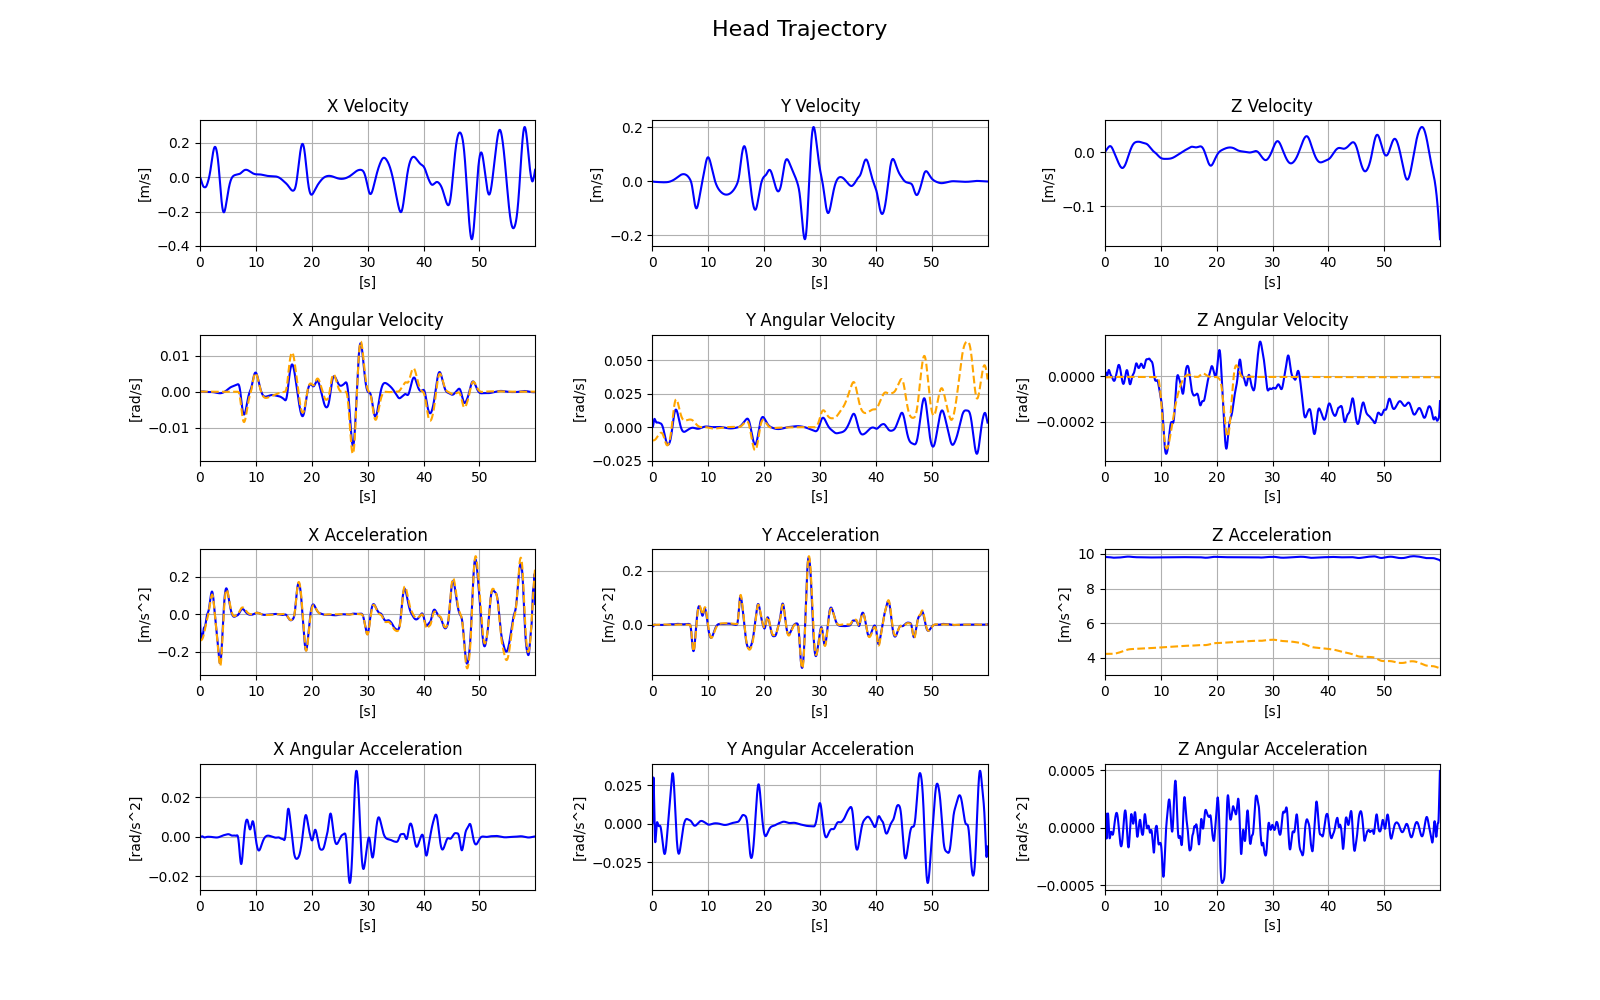

In [11]:
mpc_human_fig = viz.plot_human_trajectory(trajectory=tl, limits=limits, spec=spec, references=references)

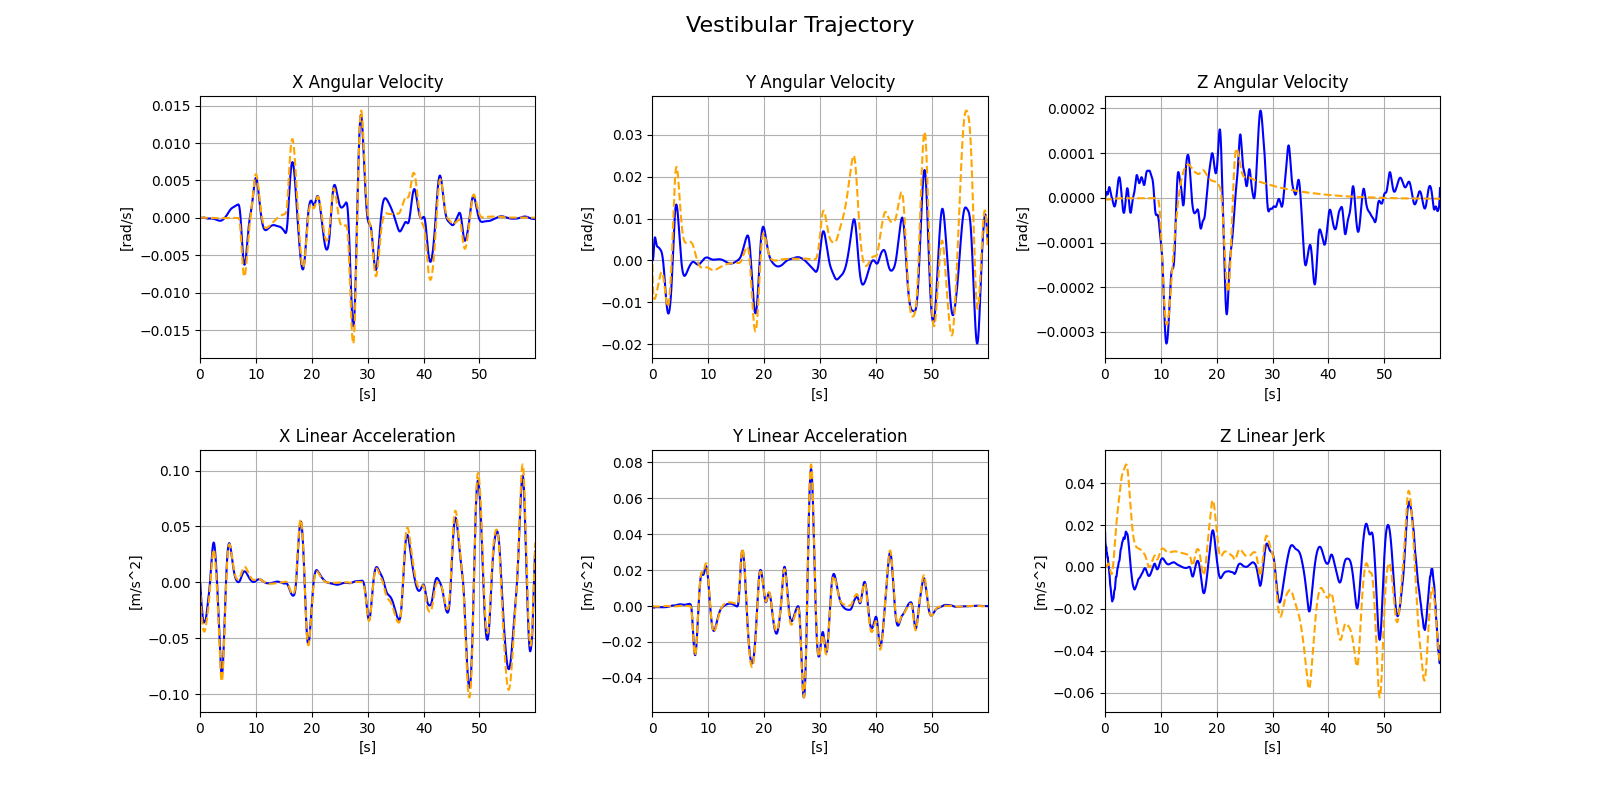

In [16]:
mpc_vestibular_fig = viz.plot_vestibular_trajectory(trajectory=tl, limits=limits, spec=spec)#, fig_kwds={"dpi": 200})

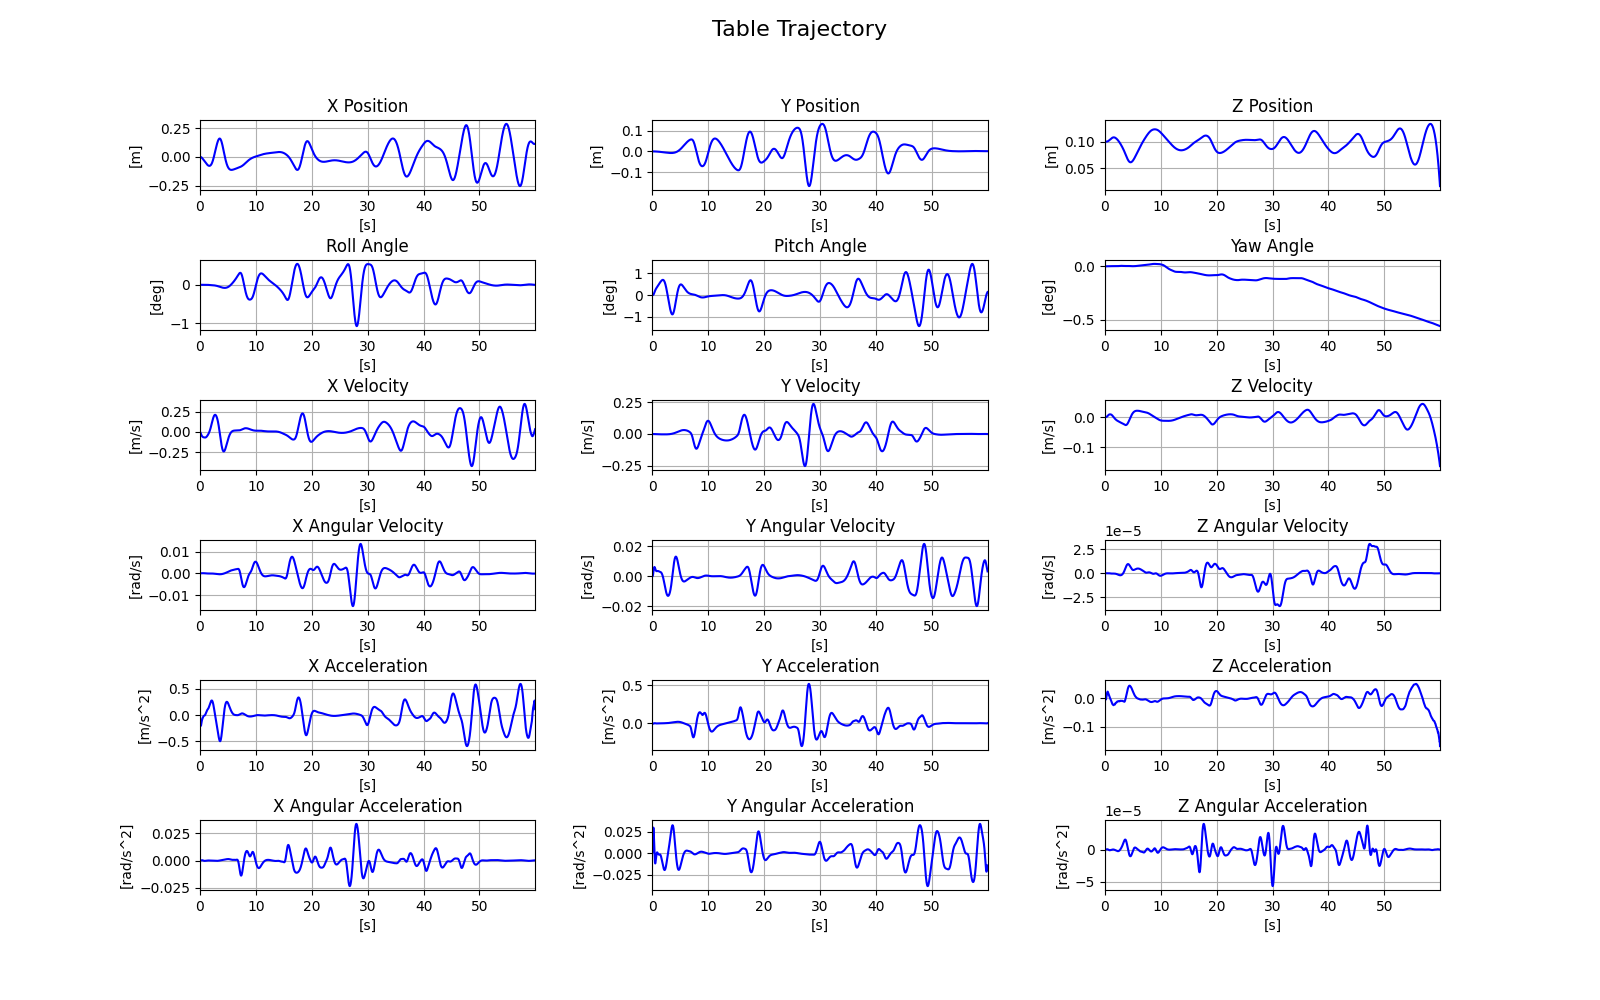

In [13]:
mpc_table_fig = viz.plot_cartesian_table_trajectory(trajectory=tl, limits=limits, spec=spec)

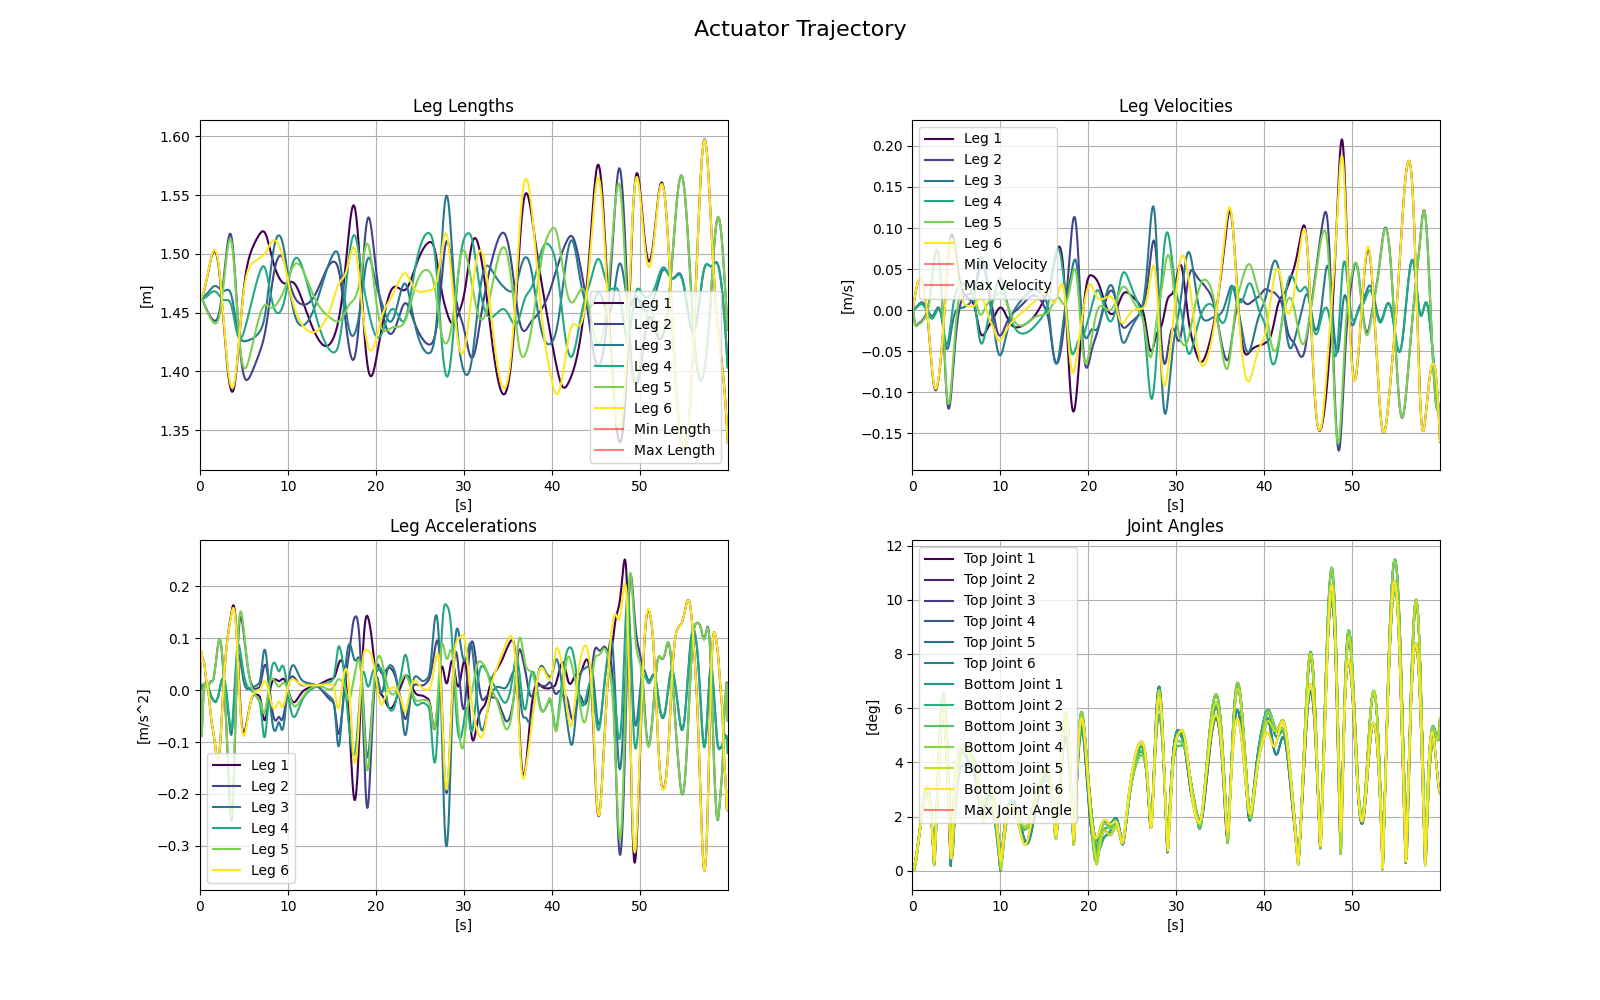

In [14]:
mpc_actuator_fig = viz.plot_actuator_trajectory(trajectory=tl, limits=limits, spec=spec)